# HW 2 - Descriptive Notebook

In this homework notebook, we will create a Wasserstein GAN with Convolution and Transpose Convolution layers for the MNIST Digit Generation dataset.

Get familiar with the code and write a small report (2 pages max), with answers to the questions listed at the end of the notebook.

**The report must be submitted in PDF format, before April 15th, 11.59pm!**

Do not forget to write your name and student ID on the report.

You may also submit your own copy of the notebook along with the report. If you do so, please add your name and ID to the cell below.

In [1]:
# Name: Sagar Pratap Singh
# Student ID: 1010736

In [2]:
# Dependencies for SUTD Cluster env
!pip install matplotlib

### Imports needed

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch import Tensor
from torch.autograd import Variable
import torch.autograd as autograd
from torchvision.utils import save_image

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(device)

cuda


### Dataset and dataloader

In [5]:
# Image transform to be applied to dataset
# - Tensor conversion
# transform = transforms.Compose([transforms.ToTensor()])
transform = transforms.Compose([                                                                                               
  transforms.ToTensor(),      
  transforms.Normalize([0.5], [0.5])                                                                                         
])   

In [6]:
# MNIST train dataset
mnist = torchvision.datasets.MNIST(root = './data/',
                                   train = True,
                                   transform = transform,
                                   download = True)

In [7]:
# Data loader
batch_size = 64
data_loader = torch.utils.data.DataLoader(dataset = mnist,
                                          batch_size = batch_size,
                                          shuffle = True)

### Critic model as a set of Conv2d layers

**Task1:** Rewrite the Critic model below, so that it uses Conv2d layers instead of fully connected ones shown in class.

You may look for inspiration in the encoder models used in Notebook 3 (W9S1 lecture).

The critic should use three Conv2d layers with progressive downsampling.

We do not advise to add more layers to the mix (BatchNorm, Dropout, etc.).

In [8]:
# Critic
class Critic(nn.Module):

    def __init__(self, image_size):
        """
        Only forced parameter will be the image size, set to 28.
        """
        super().__init__()
        assert image_size == 28, "This architecture is written for 28x28 MNIST."

        # widened the convolutional encoder from 1->16->32->1 to 1->64->128->1 to learn stronger features and provide a sharper training signal to the generator
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0)    # 7 -> 1
        )
    
    def forward(self, x):
        x = self.net(x)                  # (B, 1, 1, 1)
        return x.view(x.size(0), 1)      # (B, 1)


### Generator model as a set of Transposed Conv2d layers

**Task2:** Rewrite the Generator model below, so that it uses Transposed Conv2d layers instead of fully connected ones shown in class.

You may look for inspiration in the encoder models used in Notebooks 2 and 3 (W9S1 lecture).

The critic should use three Transposed Conv2d layers with progressive upsampling.

We do not advise to add more layers to the mix (BatchNorm, Dropout, etc.).

In [9]:
# Generator
class Generator(nn.Module):

    def __init__(self, latent_size, image_size):
        """
        Only forced parameters will be the image size, set to 28,
        and the latent size set to 64.
        """
        super().__init__()
        assert image_size == 28, "This architecture is written for 28x28 MNIST."

        # widened the transpose-convolution decoder from 64->32->16->1 style capacity to 64->128->64->1 to improve image synthesis quality and diversity 
        self.net = nn.Sequential(
          nn.ConvTranspose2d(latent_size, 128, kernel_size=7, stride=1, padding=0),   # 1 -> 7
          nn.ReLU(inplace=True),
    
          nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),             # 7 -> 14
          nn.ReLU(inplace=True),
    
          nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),              # 14 -> 28
          nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), x.size(1), 1, 1)   # (B, 64) -> (B, 64, 1, 1)
        return self.net(x)

### Trainer function

**Task 3:** Decide on a number of iterations num_epochs for training!

In [10]:
# Hyperparameters for model generation and training
latent_size = 64
image_size = 28
num_epochs = 50
lambda_gp = 10
n_critic = 5

In [11]:
# Create discriminator model
f = Critic(image_size)
f.to(device)

Critic(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 1, kernel_size=(7, 7), stride=(1, 1))
  )
)

In [12]:
# Create generator model
G = Generator(latent_size, image_size)
G.to(device)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(64, 128, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)

In [13]:
# Losses and optimizers
d_optimizer = torch.optim.Adam(f.parameters(), lr=0.0001, betas=(0.0, 0.9))
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0001, betas=(0.0, 0.9))

In [14]:
# History trackers for training curves
# Keeping track of losses
d_losses = np.zeros(num_epochs)
g_losses = np.zeros(num_epochs)

**Note: running the cell below (our trainer function) will take a long time!**

In [15]:
total_step = len(data_loader)
for epoch in range(num_epochs):
  for i, (images, _) in enumerate(data_loader):

      images = images.to(device)

      # TRAIN CRITIC (n_critic steps per G step)
      for _ in range(n_critic):
          outputs_real = f(images)

          z = torch.randn(images.size(0), latent_size).to(device)
          fake_images = G(z).detach()
          outputs_fake = f(fake_images)

          # Gradient penalty on interpolated samples
          alpha = torch.rand(images.size(0), 1, 1, 1).to(device)
          interpolated = (alpha * images + (1 - alpha) * fake_images).requires_grad_(True)
          d_interpolated = f(interpolated)

          gradients = autograd.grad(
              outputs=d_interpolated,
              inputs=interpolated,
              grad_outputs=torch.ones_like(d_interpolated),
              create_graph=True,
              retain_graph=True)[0]
          gradients = gradients.view(gradients.size(0), -1)
          gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

          d_loss = -outputs_real.mean() + outputs_fake.mean() + lambda_gp * gradient_penalty

          d_optimizer.zero_grad()
          d_loss.backward()
          d_optimizer.step()

      # NO weight clipping

      # TRAIN GENERATOR
      z = torch.randn(images.size(0), latent_size).to(device)
      fake_images = G(z)
      outputs = f(fake_images)

      g_loss = -outputs.mean()

      g_optimizer.zero_grad()
      g_loss.backward()
      g_optimizer.step()

      # LOGGING
      d_losses[epoch] = d_losses[epoch] * (i/(i+1.)) + d_loss.item() * (1./(i+1.))
      g_losses[epoch] = g_losses[epoch] * (i/(i+1.)) + g_loss.item() * (1./(i+1.))

      if (i+1) % 200 == 0:
          print('Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f}, g_loss:{:.4f}'
                .format(epoch, num_epochs, i+1, total_step,d_loss.item(), g_loss.item()))

Epoch [0/50], Step [200/938], d_loss: -18.6836, g_loss:7.7708
Epoch [0/50], Step [400/938], d_loss: -9.5115, g_loss:9.3066
Epoch [0/50], Step [600/938], d_loss: -5.4475, g_loss:15.6912
Epoch [0/50], Step [800/938], d_loss: -4.2215, g_loss:7.1434
Epoch [1/50], Step [200/938], d_loss: -3.5310, g_loss:1.2908
Epoch [1/50], Step [400/938], d_loss: -3.1774, g_loss:-1.7901
Epoch [1/50], Step [600/938], d_loss: -3.0919, g_loss:-1.0501
Epoch [1/50], Step [800/938], d_loss: -3.2359, g_loss:-5.6187
Epoch [2/50], Step [200/938], d_loss: -2.1359, g_loss:-5.9044
Epoch [2/50], Step [400/938], d_loss: -2.5195, g_loss:-6.0411
Epoch [2/50], Step [600/938], d_loss: -2.1798, g_loss:-5.7639
Epoch [2/50], Step [800/938], d_loss: -2.0650, g_loss:-7.8893
Epoch [3/50], Step [200/938], d_loss: -1.8239, g_loss:-6.7262
Epoch [3/50], Step [400/938], d_loss: -2.0751, g_loss:-5.2582
Epoch [3/50], Step [600/938], d_loss: -1.7226, g_loss:-5.2592
Epoch [3/50], Step [800/938], d_loss: -1.9905, g_loss:-6.1696
Epoch [4/50

### Visualization

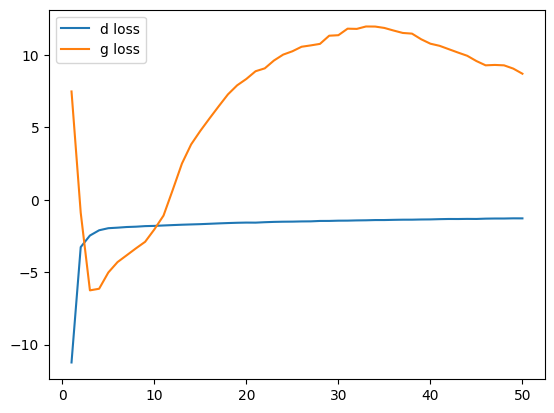

In [16]:
# Display losses for both the generator and discriminator
plt.figure()
plt.plot(range(1, num_epochs + 1), d_losses, label = 'd loss')
plt.plot(range(1, num_epochs + 1), g_losses, label = 'g loss')
plt.legend()
plt.show()

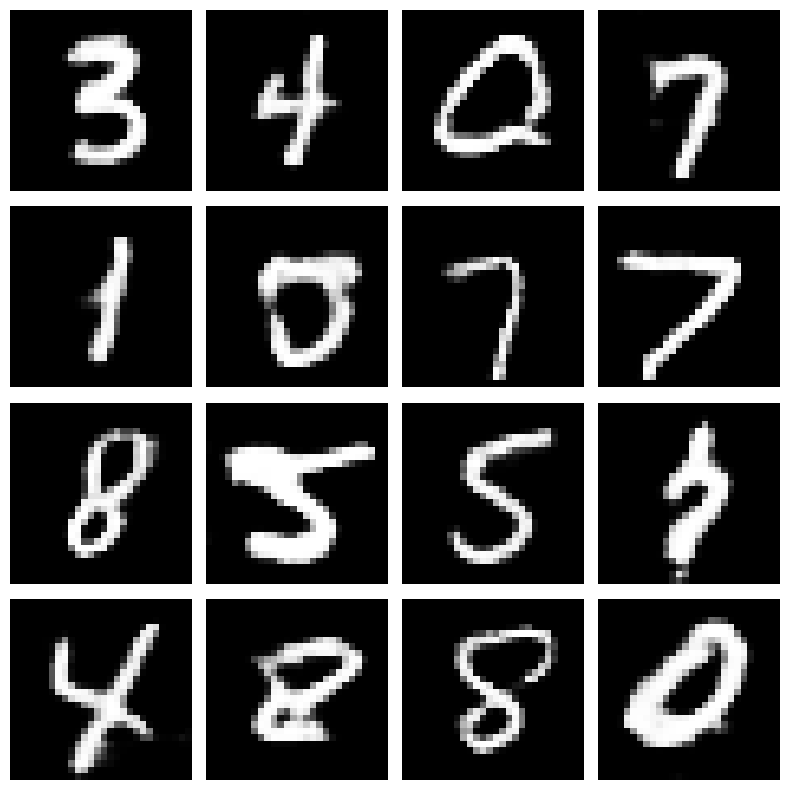

In [17]:
n_samples = 16
z = torch.randn(n_samples, latent_size).to(device)                                                                             
fake_images = G(z)                                                                                 
fake_images = fake_images.cpu().detach().numpy().reshape(n_samples, 28, 28)
fake_images = (fake_images + 1) / 2                                                                                            
                                          
fig, axes = plt.subplots(4, 4, figsize=(8, 8))                                                                                 
for idx, ax in enumerate(axes.flat):                                                               
  ax.imshow(fake_images[idx], cmap='gray')                                                                                   
  ax.axis('off')                          
plt.tight_layout()                                                                                                             
plt.show() 

### Questions and expected answers for the report

1. [15 points] Copy and paste the code for your Critic class. Briefly explain your choice of architecture.


2. [15 points] Copy and paste the code for your Generator class. Briefly explain your choice of architecture.


3. [5 points] For how many iterations did you have to train when using Wasserstein with Conv/TransposeConv layers to get plausible images from the generator? Is it training faster than the Fully Connected Wasserstein/Vanilla GAN?


4. [5 points] Display some samples generated by your trained generator. Do they look plausible?


5. [10 points] Let us assume we use Conv2d layers in the Critic. We do NOT use Transposed Conv2d layers, but only Fully Connected layers in the Generator. Would the GAN still be able to train both models or would it encounter difficulties? Discuss.

## Answers

### 1. Critic class + architecture explanation

I used three Conv2d layers with progressive downsampling from `28x28 -> 14x14 -> 7x7 -> 1x1`, which allows the critic to learn local stroke patterns and digit structure more effectively than a fully connected network. `LeakyReLU` helps maintain gradient flow, and widening the channels to `64` and `128` improved feature extraction and produced a stronger training signal for the generator. I also kept the critic simple and avoided BatchNorm, which is consistent with the homework guidance and common WGAN practice.


```python
class Critic(nn.Module):

    def __init__(self, image_size):
        """
        Only forced parameter will be the image size, set to 28.
        """
        super().__init__()
        assert image_size == 28, "This architecture is written for 28x28 MNIST."

        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 14 -> 7
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0)   # 7 -> 1
        )

    def forward(self, x):
        x = self.net(x)
        return x.view(x.size(0), 1)
```


### 2. Generator class + architecture explanation

I used three transposed convolution layers so the generator gradually upsamples a latent vector into a `28x28` image. This architecture is more appropriate for image synthesis than a fully connected generator because it explicitly models spatial structure during upsampling. I widened the channels to `128` and `64` to increase model capacity, which improved stroke thickness and overall digit quality in later experiments. I used `Tanh` at the output because the MNIST images were normalized to `[-1, 1]`, which gave smoother outputs than the earlier sigmoid-based version.


```python
class Generator(nn.Module):

    def __init__(self, latent_size, image_size):
        """
        Only forced parameters will be the image size, set to 28,
        and the latent size set to 64.
        """
        super().__init__()
        assert image_size == 28, "This architecture is written for 28x28 MNIST."

        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_size, 128, kernel_size=7, stride=1, padding=0), # 1 -> 7
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),           # 7 -> 14
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),             # 14 -> 28
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), x.size(1), 1, 1)
        return self.net(x)
```

### 3. Iterations required and training performance vs Fully connected Wasserstein/Vanilla GAN

In my experiments, training for **50 epochs** was enough to obtain plausible MNIST-like samples once I switched to a stable **WGAN-GP** setup. Earlier experiments using the original weight-clipping formulation either collapsed or produced strong visual artifacts, so the model quality was poor even after the same number of epochs. I also tested **100 epochs**, but that did not improve the results and in one case made training less stable.

**Iterative Experiments Conducted** <br>
I began with a baseline Conv/TransposeConv Wasserstein GAN, but it performed poorly because the critic quickly collapsed and the generated digits were mostly noisy. I first removed the original L6 regularization, but this had almost no effect, which showed that the main problem was actually the weight clipping. I then switched to a standard **WGAN-GP** setup by removing clipping, adding gradient penalty, and using more appropriate training settings, which made training much more stable and produced clearly better samples.

After that, I tried training for **100 epochs**, but this did not help and sometimes made the generator less stable. I then changed the output activation to **Tanh** and normalized the input images to `[-1, 1]`, which improved stroke smoothness and reduced some artifacts. Next, I widened the channels in both the critic and generator, which gave the clearest improvement in digit quality. Finally, Experiment 7 combined the best choices from earlier runs, namely **WGAN-GP, Tanh normalization, wider channels, lower learning rate, and Adam betas `(0.0, 0.9)`**, and this produced the best final result.

**Training performance comparison to Fully Connected WGAN**<br>
Compared with a Fully Connected Wasserstein GAN or Vanilla GAN, the Conv/TransposeConv version is **not necessarily faster in raw training time**. Convolutional layers are more computationally expensive, and WGAN-GP also requires multiple critic updates and gradient penalty computation. However, it is **more effective for image generation**, because convolutional architectures capture local spatial structure much better. So overall, it may train slower per epoch, but it reaches **better-quality image generation** for MNIST.


### 4. Display some samples generated by your trained generator. Do they look plausible?

Yes. The final trained generator produces several samples that have a close resemblance to MNIST handwritten digits (0,1,3,4,5,7,8). Compared with the earlier experiments, the digits in the final model have more consistent stroke thickness, better overall shapes, and fewer strong checkerboard or stripy artifacts. Some samples are still slightly blurry or ambiguous, so the model is not perfect, but the overall output is plausible and shows that the generator has learned the MNIST data distribution reasonably well.

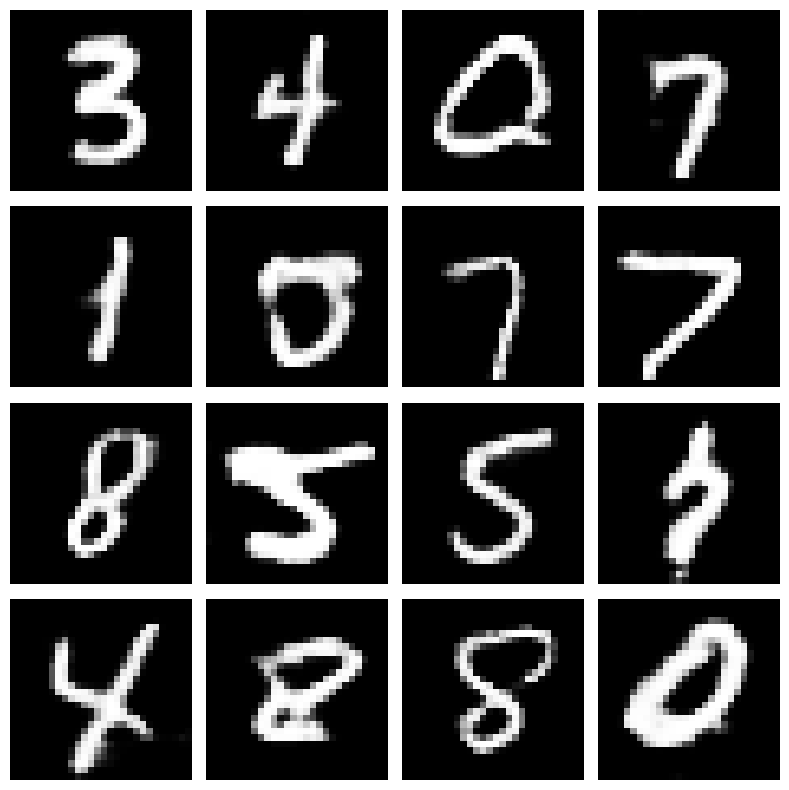

### 5. Let us assume we use Conv2d layers in the Critic. We do NOT use Transposed Conv2d layers, but only Fully Connected layers in the Generator. Would the GAN still be able to train both models or would it encounter difficulties? Discuss.

The GAN would still be able to train in principle, because a fully connected generator can still produce a vector of size `28 x 28` that can be reshaped into an image and passed to a convolutional critic. However, training would likely be more difficult and the generated images would usually be worse than with a Transposed Conv2d generator.

The main reason is that images have strong spatial structure, such as local edges, curves, and stroke continuity. A Transposed Conv2d generator builds these patterns progressively while upsampling, so it is naturally better suited for image synthesis. In contrast, a fully connected generator does not explicitly model spatial locality and has to learn all pixel relationships from scratch. This is less parameter-efficient and often leads to blurrier or less coherent outputs. Therefore, such a GAN could still train, but it would generally be less stable and less effective for generating clean MNIST-like digits.
